In [1]:
import pandas as pd
import geopandas as gpd
import requests
import json
import os
import zipfile
import folium
from dotenv import load_dotenv

In [2]:
## Bikes

stations_url = "https://gbfs.bcycle.com/bcycle_lametro/station_information.json"
status_url = "https://gbfs.bcycle.com/bcycle_lametro/station_status.json"

df_stations = pd.DataFrame(requests.get(stations_url).json()['data']['stations'])
df_status = pd.DataFrame(requests.get(status_url).json()['data']['stations'])

df_bikes = df_stations.merge(df_status, on='station_id')
print(f"Bike stations: {len(df_bikes)}")

Bike stations: 225


In [3]:
## GTFS
df_stops   = pd.read_csv("data/raw/gtfs_rail/stops.txt")
df_routes  = pd.read_csv("data/raw/gtfs_rail/routes.txt")
df_shapes  = pd.read_csv("data/raw/gtfs_rail/shapes.txt")
df_trips   = pd.read_csv("data/raw/gtfs_rail/trips.txt")

# Join shapes to routes via trips
shape_to_route = df_trips[['route_id', 'shape_id']].drop_duplicates()
shape_to_route = shape_to_route.merge(
    df_routes[['route_id', 'route_long_name', 'route_color']],
    on='route_id'
)

# Filter actual stops only
df_stops_only = df_stops[df_stops['location_type'] == 0]

print(f"Rail stops: {len(df_stops_only)}")
print(f"Routes: {len(df_routes)}")

# Bus stops
df_bus_stops = pd.read_csv("data/raw/gtfs_bus/stops.txt")
print(f"Bus stops: {len(df_bus_stops)}")

Rail stops: 111
Routes: 6
Bus stops: 11881


In [4]:
# Census data

load_dotenv()
CENSUS_KEY = os.getenv("CENSUS_API_KEY")

census_url = (
    f"https://api.census.gov/data/2022/acs/acs5"
    f"?get=NAME,"
    f"B19013_001E,"  # median household income
    f"B19301_001E,"  # per capita income
    f"B19083_001E,"  # gini index
    f"B17001_002E,"  # population below poverty
    f"B01003_001E,"  # total population
    f"B25010_001E,"  # average household size
    f"B08201_002E,"  # no vehicle households
    f"B08201_001E,"  # total households
    f"B08301_001E,"  # total workers
    f"B08301_010E,"  # transit commuters
    f"B08301_016E,"  # bike commuters
    f"B08301_019E,"  # walk commuters
    f"B08301_021E,"  # work from home
    f"B08303_001E"   # mean travel time
    f"&for=tract:*"
    f"&in=state:06%20county:037"
    f"&key={CENSUS_KEY}"
)

response = requests.get(census_url)
census_data = response.json()
df_census = pd.DataFrame(census_data[1:], columns=census_data[0])

df_census = df_census.rename(columns={
    'B19013_001E': 'median_income',
    'B19301_001E': 'per_capita_income',
    'B19083_001E': 'gini_index',
    'B17001_002E': 'pop_below_poverty',
    'B01003_001E': 'total_population',
    'B25010_001E': 'avg_household_size',
    'B08201_002E': 'no_vehicle_households',
    'B08201_001E': 'total_households',
    'B08301_001E': 'total_workers',
    'B08301_010E': 'transit_commuters',
    'B08301_016E': 'bike_commuters',
    'B08301_019E': 'walk_commuters',
    'B08301_021E': 'wfh_commuters',
    'B08303_001E': 'mean_travel_time'
})

cols = [
    'median_income', 'per_capita_income', 'gini_index',
    'pop_below_poverty', 'total_population', 'avg_household_size',
    'no_vehicle_households', 'total_households', 'total_workers',
    'transit_commuters', 'bike_commuters', 'walk_commuters',
    'wfh_commuters', 'mean_travel_time'
]
df_census[cols] = df_census[cols].apply(pd.to_numeric, errors='coerce')

pct_calculations = {
    'pct_no_vehicle': ('no_vehicle_households', 'total_households'),
    'pct_transit':    ('transit_commuters',      'total_workers'),
    'pct_bike':       ('bike_commuters',          'total_workers'),
    'pct_walk':       ('walk_commuters',           'total_workers'),
    'pct_wfh':        ('wfh_commuters',            'total_workers'),
    'pct_poverty':    ('pop_below_poverty',         'total_population'),
}

for new_col, (numerator, denominator) in pct_calculations.items():
    df_census[new_col] = (
        df_census[numerator] / df_census[denominator] * 100
    ).round(1)

print(f"Census tracts: {len(df_census)}")


Census tracts: 2498


In [5]:
gdf_tracts = gpd.read_file("data/raw/ca_tracts/tl_2022_06_tract.shp")
gdf_la = gdf_tracts[gdf_tracts['COUNTYFP'] == '037'].copy()
gdf_la = gdf_la.to_crs(epsg=4326)

df_census['GEOID'] = (
    df_census['state'] +
    df_census['county'] +
    df_census['tract']
)

gdf_merged = gdf_la.merge(df_census, on='GEOID')

print(f"Merged tracts: {len(gdf_merged)}")
print(gdf_merged[['GEOID', 'median_income', 'pct_no_vehicle', 'geometry']].head(3))

Merged tracts: 2498
         GEOID  median_income  pct_no_vehicle  \
0  06037137504         203750             2.9   
1  06037138000         130690             1.3   
2  06037139200          94250             3.4   

                                            geometry  
0  POLYGON ((-118.58119 34.14318, -118.581 34.143...  
1  POLYGON ((-118.60573 34.14585, -118.60561 34.1...  
2  POLYGON ((-118.53083 34.18024, -118.52952 34.1...  


In [6]:
# notes 
# # Option: rename before merge to avoid collision
# df_census = df_census.rename(columns={'NAME': 'tract_name'})

In [7]:
# ============================================================
# CELL 7 — Choropleth Map
# Visualizes census demographics layered with transit and bikes
# ============================================================

# branca is folium's companion library for color scales
from branca.colormap import LinearColormap

# --- BASE MAP ---
# CartoDB positron = clean, light, minimal basemap — NYT style
# zoom_start=10 shows all of LA County at once
m = folium.Map(
    location=[34.0522, -118.2437],  # center of LA
    zoom_start=10,
    tiles="CartoDB positron"
)

# --- CLEAN THE DATA ---
# Drop tracts where income is 0 or negative
# These are Census artifacts — unpopulated areas, parks, airports
gdf_map = gdf_merged[gdf_merged['median_income'] > 0].copy()

# --- BUILD COLOR SCALE ---
# LinearColormap maps a value range to a list of colors
# We use quantiles (0.05, 0.95) instead of min/max
# to avoid extreme outliers skewing the entire color scale
# Red = low income, Blue = high income
colormap = LinearColormap(
    colors=['#d73027', '#fc8d59', '#fee090', '#e0f3f8', '#91bfdb', '#4575b4'],
    vmin=gdf_map['median_income'].quantile(0.05),  # 5th percentile as floor
    vmax=gdf_map['median_income'].quantile(0.95),  # 95th percentile as ceiling
    caption='Median Household Income ($)'          # legend label
)

# --- CHOROPLETH LAYER: Census Tracts ---
# GeoJson renders each polygon with a style based on its properties
# style_function runs once per feature — it receives the GeoJSON feature
# and returns a dict of CSS-like style properties
folium.GeoJson(
    gdf_map,
    name="Median Income",
    style_function=lambda feature: {
        # colormap() converts a number to a hex color
        # the 'if' guard handles any remaining None values
        'fillColor': colormap(feature['properties']['median_income'])
            if feature['properties']['median_income'] else '#gray',
        'color': 'white',       # polygon border color
        'weight': 0.3,          # border thickness — thin keeps it clean
        'fillOpacity': 0.7      # slightly transparent so basemap shows through
    },
    # tooltip appears on hover — fields must exist in gdf_map columns
    # aliases = human readable labels shown in the tooltip
tooltip=folium.GeoJsonTooltip(
    fields=['NAME_y', 'median_income', 'pct_no_vehicle', 'pct_transit'],
    aliases=['Tract', 'Median Income ($)', 'No Vehicle (%)', 'Transit Commuters (%)'],
    localize=True
)
).add_to(m)

# Add the color legend to the map
colormap.add_to(m)

# --- RAIL LINES in Metro colors ---
# FeatureGroup lets us toggle this layer independently
rail_layer = folium.FeatureGroup(name="Rail Lines", show=True)
for _, shape_row in shape_to_route.iterrows():
    shape_id = shape_row['shape_id']
    color    = f"#{shape_row['route_color']}"  # color comes from routes.txt

    # Get all points for this shape, sorted by sequence
    # then convert to list of [lat, lon] pairs for PolyLine
    points = df_shapes[df_shapes['shape_id'] == shape_id]\
        .sort_values('shape_pt_sequence')[['shape_pt_lat', 'shape_pt_lon']]\
        .values.tolist()

    if points:  # guard against empty shapes
        folium.PolyLine(
            points,
            color=color,
            weight=4,
            opacity=0.9,
            tooltip=shape_row['route_long_name']  # hover shows line name
        ).add_to(rail_layer)
rail_layer.add_to(m)

# --- BIKE SHARE STATIONS ---
bike_layer = folium.FeatureGroup(name="Bike Share", show=True)
for _, row in df_bikes.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=4,
        color='#E63946',   # red accent — stands out against blue choropleth
        fill=True,
        fill_opacity=0.8,
        # popup appears on click — shows live availability
        popup=folium.Popup(
            f"<b>{row['name']}</b><br>"
            f"Bikes: {row['num_bikes_available']}<br>"
            f"Docks: {row['num_docks_available']}",
            max_width=200
        )
    ).add_to(bike_layer)
bike_layer.add_to(m)

# --- BUS STOPS ---
# show=False means this layer is off by default
# Very subtle styling — just coverage context, not the focus
bus_layer = folium.FeatureGroup(name="Bus Stops", show=False)
for _, row in df_bus_stops.iterrows():
    folium.CircleMarker(
        location=[row['stop_lat'], row['stop_lon']],
        radius=1,
        color='#AAAAAA',
        fill=True,
        fill_opacity=0.3
    ).add_to(bus_layer)
bus_layer.add_to(m)

# --- LAYER CONTROL ---
# collapsed=False keeps the panel open by default
# Each FeatureGroup appears as a toggle in the panel
folium.LayerControl(collapsed=False).add_to(m)

# --- SAVE ---
m.save("data/processed/map_v4.html")
print("Map v4 saved")



Map v4 saved


In [8]:
## Saving data

In [11]:
# Save gdf_merged as GeoJSON (preserves geometry + all columns)
gdf_merged.to_file("data/processed/gdf_merged.geojson", driver="GeoJSON")

# Save df_bikes as CSV (no geometry needed)
df_bikes.to_csv("data/processed/bikes.csv", index=False)

# Save rail stops as CSV
df_stops_only.to_csv("data/processed/rail_stops.csv", index=False)

df_census.to_csv("data/processed/census.csv", index=False)

print("All processed data saved")
print(f"  gdf_merged: {len(gdf_merged)} tracts")
print(f"  df_bikes:   {len(df_bikes)} stations")
print(f"  rail stops: {len(df_stops_only)} stops")
print(f"census: {len(df_census)} tracts")


All processed data saved
  gdf_merged: 2498 tracts
  df_bikes:   225 stations
  rail stops: 111 stops
census: 2498 tracts


## Working with OSM data


In [21]:
import osmnx as ox
bike_lanes = ox.features_from_place(
    "Los Angeles County, California, USA",
    tags={"highway": "cycleway"}   # dedicated bike paths
)

# Filter to lines only — nodes are just points, not useful for lanes
bike_lanes_osm = bike_lanes[bike_lanes.geometry.geom_type == "LineString"].copy()

# Keep only useful columns
bike_lanes_osm = bike_lanes_osm[["geometry", "highway", "name", "surface"]].reset_index()

print(f"OSM bike lines: {len(bike_lanes_osm)}")
print(bike_lanes_osm.head(3))

OSM bike lines: 3686
  element       id                                           geometry  \
0     way  4341140  LINESTRING (-118.44558 33.97005, -118.44554 33...   
1     way  4341259  LINESTRING (-118.48244 33.99653, -118.48236 33...   
2     way  4341259  LINESTRING (-118.48244 33.99653, -118.48236 33...   

    highway                    name   surface  
0  cycleway                     NaN     paved  
1  cycleway  Venice Beach Bike Path  concrete  
2  cycleway  Venice Beach Bike Path  concrete  


Text(0.5, 1.0, 'OSM Bike Infrastructure — LA County')

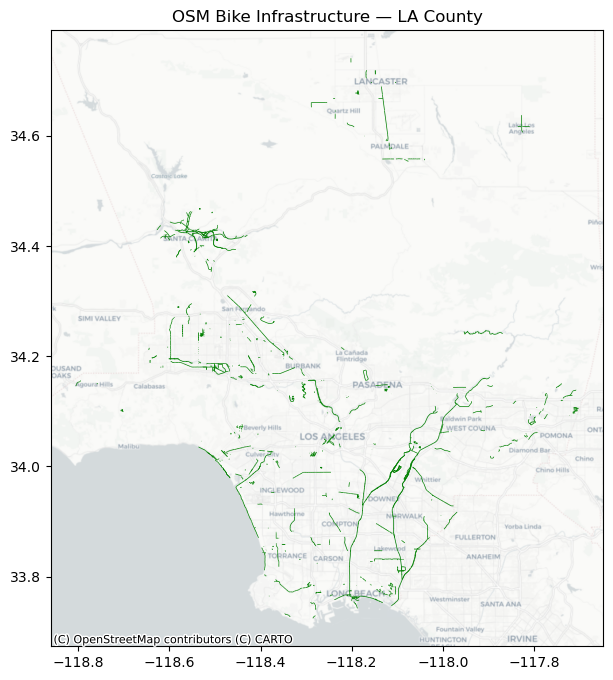

In [24]:
## Map visual
ax = bike_lanes_osm.plot(figsize=(10, 8), color='green', linewidth=0.5)

# contextily adds a basemap tile underneath
import contextily as ctx
ctx.add_basemap(ax, crs=bike_lanes_osm.crs.to_string(), source=ctx.providers.CartoDB.Positron)

ax.set_title("OSM Bike Infrastructure — LA County")

In [28]:


# ── 1. LA CITY BIKE LANES (GeoJSON direct) ──────────────────────────
print("Fetching bike lanes...")
bike_url = (
    "https://services1.arcgis.com/tp9wqSVX1AitKgjd/arcgis/rest/services/"
    "LA_City_Bikeways/FeatureServer/0/query?outFields=*&where=1%3D1&f=geojson"
)
response = requests.get(bike_url)
bike_lanes_la = gpd.read_file(BytesIO(response.content))
print(f"LA bike lanes: {len(bike_lanes_la)} features")
print(bike_lanes_la.columns.tolist())



Fetching bike lanes...
LA bike lanes: 1000 features
['OBJECTID', 'ASSETID', 'SECT_ID', 'flag', 'InputDate', 'Update_Date', 'Install_Da', 'FY', 'Year_', 'ST_NAME', 'ST_FROM', 'ST_TO', 'Comments', 'Limits', 'Class', 'Project_Name', 'Bikeway', 'Project_Type', 'RetireType', 'Retire', 'Upgraded_From', 'ST_TYPE', 'STREET_DES', 'ST_WIDTH', 'CL_Miles', 'Lane_Miles', 'CD', 'Network', 'Region', 'One_Dir_BW', 'CHECKED', 'Tag', 'OTHER', 'MP2035_Network', 'INTERU_FLAG', 'ClassIV_Protection', 'ClassIV_Protection_Notes', 'ClassIV_Protection_Type', 'Compare', 'Bikeway_ID', 'GlobalID', 'Shape__Length', 'geometry']


In [31]:
import rioxarray
import rasterio
import requests

# SRTM data is served as tiles — LA County falls in tile n34_w119
# strm 13 06 is data from the area of Interest

srtm_url = "https://srtm.csi.cgiar.org/wp-content/uploads/files/srtm_5x5/TIFF/srtm_13_06.zip"

print("Downloading elevation tile...")
response = requests.get(srtm_url, stream=True)

# Save the zip file
with open("data/raw/srtm_la.zip", "wb") as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)

print(f"Downloaded: {response.status_code}")

Downloaded: 200


In [31]:
import rioxarray
import rasterio
import requests

# SRTM data is served as tiles — LA County falls in tile n34_w119
# strm 13 06 is data from the area of Interest

srtm_url = "https://srtm.csi.cgiar.org/wp-content/uploads/files/srtm_5x5/TIFF/srtm_13_06.zip"

print("Downloading elevation tile...")
response = requests.get(srtm_url, stream=True)

# Save the zip file
with open("data/raw/srtm_la.zip", "wb") as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)

print(f"Downloaded: {response.status_code}")

Downloaded: 200


In [32]:
print(f"Status code: {response.status_code}")
print(f"File size: {os.path.getsize('data/raw/srtm_la.zip') / 1024 / 1024:.1f} MB")

Status code: 200
File size: 19.6 MB


In [34]:

# Extract the zip
with zipfile.ZipFile("data/raw/srtm_la.zip", "r") as zip_ref:
    print("Contents:", zip_ref.namelist())
    zip_ref.extractall("data/raw/srtm_la/")

print("Extracted")

Contents: ['readme.txt', 'srtm_13_06.hdr', 'srtm_13_06.tfw', 'srtm_13_06.tif']
Extracted


Shape:      (1, 6000, 6000)
CRS:        EPSG:4326
Bounds:     (-120.0, 30.0, -115.0, 35.0)
Resolution: (0.0008333333333333334, -0.0008333333333333334)


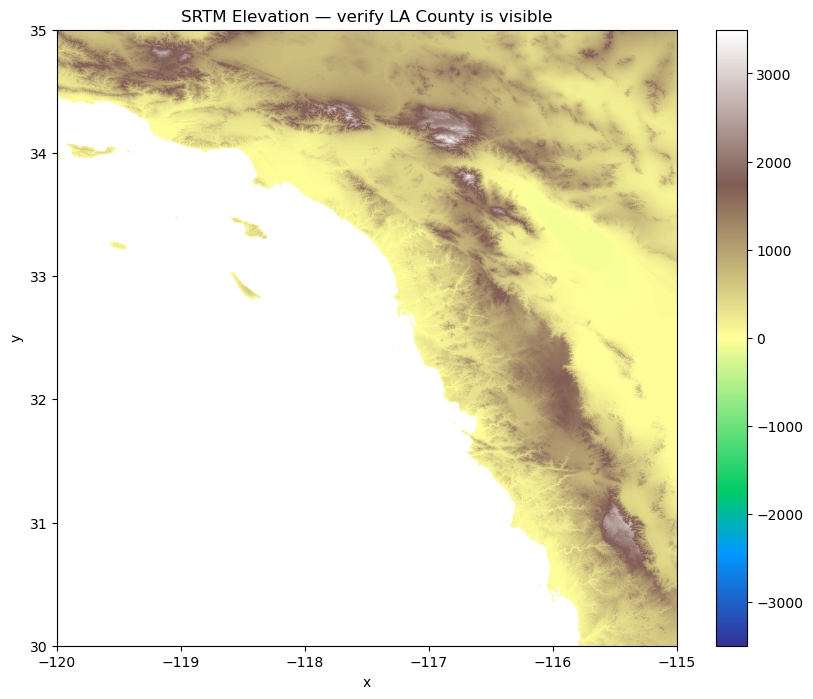

In [37]:
import rioxarray as rxr
import matplotlib.pyplot as plt

dem = rxr.open_rasterio("data/raw/srtm_la/srtm_13_06.tif", masked=True)

# Basic info — dimensions, resolution, CRS
print(f"Shape:      {dem.shape}")        # bands, rows, cols
print(f"CRS:        {dem.rio.crs}")      # coordinate system
print(f"Bounds:     {dem.rio.bounds()}") # west, south, east, north
print(f"Resolution: {dem.rio.resolution()}") # pixel size in degrees

# Quick plot to visually confirm it's LA
fig, ax = plt.subplots(figsize=(10, 8))
dem.plot(ax=ax, cmap='terrain')  # terrain colormap = green valleys, brown peaks
ax.set_title("SRTM Elevation — verify LA County is visible")
plt.show()


In [38]:
## lets double this information



In [46]:
# Define all tiles needed with their own output filenames
tiles = [
    ("https://srtm.csi.cgiar.org/wp-content/uploads/files/srtm_5x5/TIFF/srtm_12_05.zip", "data/raw/srtm_tile2.zip"),
    ("https://srtm.csi.cgiar.org/wp-content/uploads/files/srtm_5x5/TIFF/srtm_13_05.zip", "data/raw/srtm_tile3.zip"),
]

for url, filepath in tiles:
    print(f"Downloading {url.split('/')[-1]}...")  # print just the filename
    response = requests.get(url, stream=True)
    
    with open(filepath, "wb") as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    
    print(f"  Status: {response.status_code}")
    print(f"  Size:   {os.path.getsize(filepath) / 1024 / 1024:.1f} MB")

print("All tiles downloaded")

  Status: 200
  Size:   19.7 MB
  Status: 200
  Size:   39.9 MB
All tiles downloaded


data/raw/srtm_la.zip contents: ['readme.txt', 'srtm_13_06.hdr', 'srtm_13_06.tfw', 'srtm_13_06.tif']
data/raw/srtm_tile2.zip contents: ['readme.txt', 'srtm_12_05.hdr', 'srtm_12_05.tfw', 'srtm_12_05.tif']
data/raw/srtm_tile3.zip contents: ['readme.txt', 'srtm_13_05.hdr', 'srtm_13_05.tfw', 'srtm_13_05.tif']
Merged bounds: (-125.0, 30.0, -115.0, 40.0)


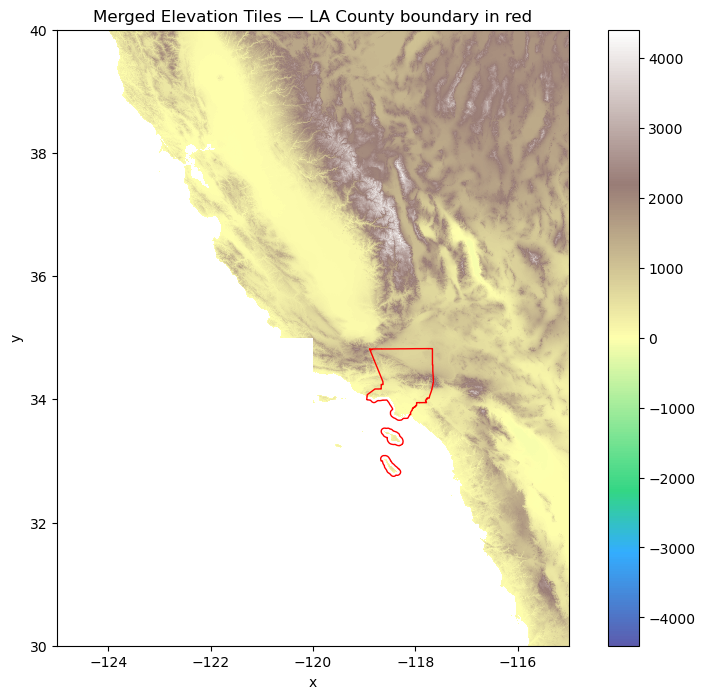

In [48]:
from rioxarray.merge import merge_arrays

# Extract all three tiles to their own folders
extract_jobs = [
    ("data/raw/srtm_la.zip",    "data/raw/srtm_la/"),     # tile 1 — already downloaded
    ("data/raw/srtm_tile2.zip", "data/raw/srtm_tile2/"),  # tile 2
    ("data/raw/srtm_tile3.zip", "data/raw/srtm_tile3/"),  # tile 3
]

for zip_path, extract_dir in extract_jobs:
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        print(f"{zip_path} contents: {zip_ref.namelist()}")
        zip_ref.extractall(extract_dir)

# Open all three tiles
dem1 = rxr.open_rasterio("data/raw/srtm_la/srtm_13_06.tif",       masked=True)
dem2 = rxr.open_rasterio("data/raw/srtm_tile2/srtm_12_05.tif",    masked=True)
dem3 = rxr.open_rasterio("data/raw/srtm_tile3/srtm_13_05.tif",    masked=True)

# Merge into one continuous raster
dem_merged = merge_arrays([dem1, dem2, dem3])
print(f"Merged bounds: {dem_merged.rio.bounds()}")

# Plot merged raster + LA county boundary as spatial reference
fig, ax = plt.subplots(figsize=(10, 8))
dem_merged.plot(ax=ax, cmap='terrain', alpha=0.8)
gdf_la.dissolve().boundary.plot(ax=ax, color='red', linewidth=1)
ax.set_title("Merged Elevation Tiles — LA County boundary in red")
plt.show()



Clipped elevation saved


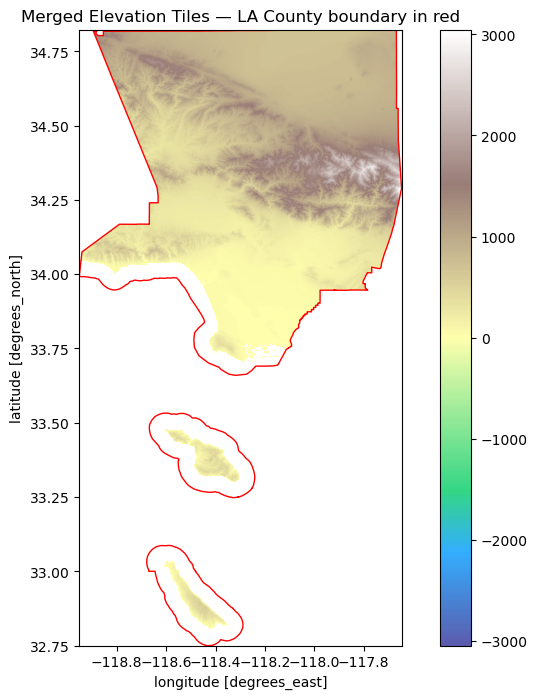

In [51]:
# Save clipped DEM for later use
dem_clipped.rio.to_raster("data/processed/la_elevation_clipped.tif")
print("Clipped elevation saved")
fig, ax = plt.subplots(figsize=(10, 8))
dem_clipped.plot(ax=ax, cmap='terrain', alpha=0.8)
gdf_la.dissolve().boundary.plot(ax=ax, color='red', linewidth=1)
ax.set_title("Merged Elevation Tiles — LA County boundary in red")
plt.show()


Slope range: 0.0% — 163.9%
Mean slope:  16.3%


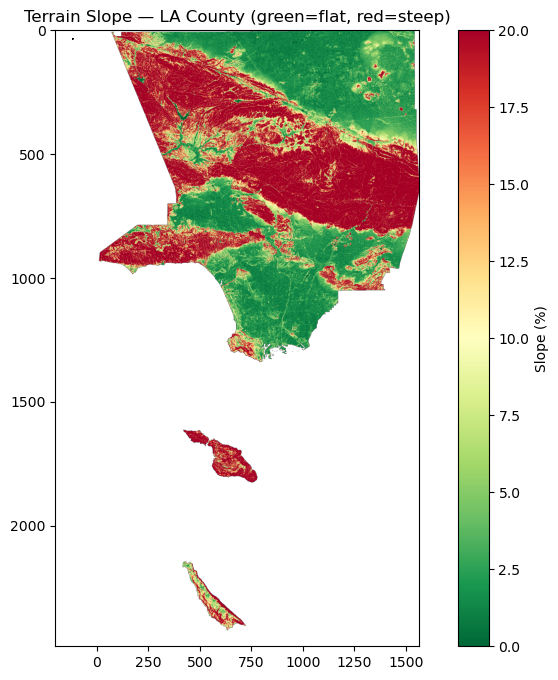

In [52]:
import numpy as np

# Calculate slope from elevation
# squeeze() removes the band dimension — raster has shape (1, rows, cols)
# we need (rows, cols) for the calculation
dem_array = dem_clipped.squeeze().values  # convert to numpy array

# Get pixel size in degrees from the raster
res = dem_clipped.rio.resolution()
x_res = abs(res[0])  # width of each pixel in degrees
y_res = abs(res[1])  # height of each pixel in degrees

# Convert degrees to meters (approximate for LA's latitude)
# 1 degree latitude ≈ 111,000 meters
# 1 degree longitude ≈ 111,000 * cos(latitude) meters
lat = 34.0  # approximate center latitude of LA
x_res_m = x_res * 111000 * np.cos(np.radians(lat))
y_res_m = y_res * 111000

# Calculate gradient (rise) in x and y directions
# np.gradient computes the rate of change between neighboring pixels
dy, dx = np.gradient(dem_array, y_res_m, x_res_m)

# Slope in percent = (rise / run) * 100
slope = np.sqrt(dx**2 + dy**2) * 100

print(f"Slope range: {np.nanmin(slope):.1f}% — {np.nanmax(slope):.1f}%")
print(f"Mean slope:  {np.nanmean(slope):.1f}%")

# Plot slope map
fig, ax = plt.subplots(figsize=(10, 8))
slope_plot = ax.imshow(
    slope,
    cmap='RdYlGn_r',   # red = steep, green = flat
    vmin=0, vmax=20    # cap at 20% so flat areas show detail
)
plt.colorbar(slope_plot, ax=ax, label='Slope (%)')
gdf_la.dissolve().to_crs(dem_clipped.rio.crs).boundary.plot(
    ax=ax, color='black', linewidth=0.8
)
ax.set_title("Terrain Slope — LA County (green=flat, red=steep)")
plt.show()

In [60]:
from rasterstats import zonal_stats

# zonal_stats calculates statistics for each polygon
# using the raster values that fall inside it
# think of it as: for each census tract, summarize all slope pixels inside

# First save slope as a raster file so rasterstats can read it
import rasterio
from rasterio.transform import from_bounds

# Get spatial reference from clipped DEM
transform = dem_clipped.rio.transform()
crs = dem_clipped.rio.crs

# Save slope as GeoTIFF
with rasterio.open(
    "data/processed/la_slope.tif",
    'w',
    driver='GTiff',
    height=slope.shape[0],
    width=slope.shape[1],
    count=1,
    dtype=slope.dtype,
    crs=crs,
    transform=transform
) as dst:
    dst.write(slope, 1)

from rasterstats import zonal_stats

# Reproject tracts to match raster CRS before aggregating
gdf_la_slope = gdf_la.to_crs(dem_clipped.rio.crs)

# zonal_stats — for each tract polygon, calculate slope statistics
# from all raster pixels that fall inside it
stats = zonal_stats(
    gdf_la_slope,                        # vector polygons
    "data/processed/la_slope.tif",       # raster file
    stats=["mean", "median", "max"],     # what to calculate per polygon
    nodata=-9999                         # ignore nodata pixels
)

# Convert results list to DataFrame and join back to tracts
df_slope = pd.DataFrame(stats)
df_slope.columns = ['slope_mean', 'slope_median', 'slope_max']

# Join to gdf_merged
df_slope.columns = ['slope_max', 'slope_mean', 'slope_median']

# Reassign to gdf_merged
gdf_merged['slope_mean']   = df_slope['slope_mean'].values
gdf_merged['slope_median'] = df_slope['slope_median'].values
gdf_merged['slope_max']    = df_slope['slope_max'].values

# Verify — max should always be >= mean >= median
print(gdf_merged[['GEOID', 'slope_mean', 'slope_median', 'slope_max']].head(5))

print(f"Slope stats added to {len(gdf_merged)} tracts")
print(gdf_merged[['GEOID', 'slope_mean', 'slope_median', 'slope_max']].head(5))



         GEOID  slope_mean  slope_median  slope_max
0  06037137504   15.517113     14.071072  39.831318
1  06037138000   12.636160     12.267635  31.354460
2  06037139200    1.820609      1.747791   3.787437
3  06037143200    1.778921      1.720832   4.843591
4  06037201301    9.382747      8.896590  24.987738
Slope stats added to 2498 tracts
         GEOID  slope_mean  slope_median  slope_max
0  06037137504   15.517113     14.071072  39.831318
1  06037138000   12.636160     12.267635  31.354460
2  06037139200    1.820609      1.747791   3.787437
3  06037143200    1.778921      1.720832   4.843591
4  06037201301    9.382747      8.896590  24.987738


In [62]:
# Check what zonal_stats actually returned
print(stats[0])  # look at the first tract's raw output

{'max': 39.83131790161133, 'mean': 15.517112832509417, 'median': 14.07107162475586}
